In [ ]:
%config InlineBackend.figure_formats = ['svg']
import numpy as np  # noqa
import matplotlib as mpl  # noqa
import matplotlib.pyplot as plt  # noqa
import quimb as qu  # noqa
import xyzpy as xyz  # noqa
import autoray as ar  # noqa
import cotengra as ctg  # noqa
import quimb.tensor as qtn  # noqa
import sys

mpl.style.use(xyz.get_neutral_style(draw_color="black"))

from quimb.schematic import get_color

sys.path.append("..")

import simpclustlib

mpl.rcParams["font.family"] = "Inter"

/media/johnnie/Storage2TB/Sync/work/simpclust/tn-loop-cluster-expansions/figs/../simpclustlib.py:19: FutureWarning: The module 'quimb.tensor.tensor_arbgeom' is deprecated and will be removed in a future release. Most functionality can be still be accessed directly from 'quimb.tensor' instead. The actual implementations have moved to `quimb.tensor.tnag.core`.
  from quimb.tensor.tensor_arbgeom import TensorNetworkGenVector


In [2]:
mode = "wynn4"
mode_err = "wynn"
y = (
    "energy_gloop_expand"
    # "energy_gloop_expand_norm_sum"
)

# TFIM 3d

In [3]:
# yest = "energy_wynn"
# yerr = "energy_wynn_error"
yest = "energy_estimate"
yerr = "energy_estimate_error"

In [4]:
model = "tfim_hz-5"
geom = "cubic_pbc"
L = 10

ds = xyz.load_ds(f"../data/energy_gloop_expand_{model}_{geom}.h5").squeeze()
ref = simpclustlib.get_energy_reference(model, geom, L)
simpclustlib.estimate_gloop_stats_into_ds(
    ds, y=y, mode=mode, mode_err=mode_err
)

datax = ds.sel(L=L)["D"].values
datay = ds.sel(L=L)[yest].values
dataye = ds.sel(L=L)[yerr].values

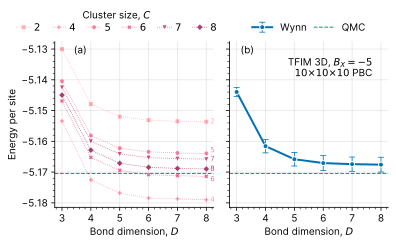

In [5]:
cm = xyz.cmoke(+0.0, reverse=True, hue_shift=+0.1)

max_sizes = [2, 4, 5, 6, 7, 8, 9, 10]
clust_colors = dict(zip(max_sizes, cm(np.linspace(0.0, 1.0, len(max_sizes)))))
# clust_markers = {C: f"${C}$" for C in [2, 4, 5, 6, 7, 8, 9, 10]}
clust_markers = {C: "." for C in clust_colors}

clust_markers = dict(
    zip(
        clust_colors,
        (
            "s",
            "P",
            "o",
            "X",
            "v",
            "D",
            "^",
            "h",
            "p",
            "*",
            "<",
            "d",
            "8",
            ">",
            "H",
        ),
    )
)

clust_linestyle = ":"
clust_linewidth = 0.75
clust_markersize = 4

fig, axs = plt.subplots(
    1, 2, figsize=(6, 3), sharey=True, gridspec_kw={"wspace": 0.1}
)

capsize = 3
elinewidth = 0.75
capthick = elinewidth
color_wynn = (
    get_color("bluedark")
    # "black"
)

wynn_style = dict(
    linewidth=2.0,
    color=color_wynn,
    marker="o",
    markeredgecolor="white",
    markersize=5,
    capsize=capsize,
    elinewidth=elinewidth,
    capthick=capthick,
)

# --------------------------------------------------------------------------- #

model = "tfim_hz-5"
geom = "cubic_pbc"
L = 10

ds = xyz.load_ds(f"../data/energy_gloop_expand_{model}_{geom}.h5").squeeze()
ref = simpclustlib.get_energy_reference(model, geom, L)
simpclustlib.estimate_gloop_stats_into_ds(
    ds, y=y, mode=mode, mode_err=mode_err
)

ds = ds.sel(D=slice(3, None))

datax = ds.sel(L=L)["D"].values
datay = ds.sel(L=L)[yest].values
dataye = ds.sel(L=L)[yerr].values
# dataye = None

ax = axs[1]
ax.text(0.07, 0.93, "(b)", transform=ax.transAxes)
ax.set(
    xlabel="Bond dimension, $D$",
    xticks=[2, 3, 4, 5, 6, 7, 8],
)

hand0 = ax.errorbar(
    datax,
    datay,
    dataye,
    **wynn_style,
    label="Wynn",
)
# ax.set_ylim(-5.185, -5.11)
ax.text(
    0.9,
    0.9,
    "TFIM 3D, $B_X=-5$\n$10{{\\times}}10{{\\times}}10$ PBC",
    transform=ax.transAxes,
    horizontalalignment="right",
    verticalalignment="top",
    # fontsize=10,
)
hand1 = ax.axhline(ref, color=get_color("green"), ls="--", lw=1, label="QMC")

ax.legend(
    handles=[hand0, hand1],
    loc="lower center",
    bbox_to_anchor=(0.5, 1.0),
    ncol=2,
    columnspacing=0.7,
)

ax = axs[0]
ax.set_ylabel("Energy per site")
ax.set(
    xlabel="Bond dimension, $D$",
    xticks=[2, 3, 4, 5, 6, 7, 8],
)

ax.axhline(ref, color=get_color("green"), ls="--", lw=1, zorder=-11)
label_offsets = {5: 0.001, 6: -0.001}

for max_size in ds["max_size"].values:
    datax = ds.sel(L=L)["D"].values
    datay = ds.sel(L=L, max_size=max_size)[y].values
    max_size = max(2, max_size)
    ax.plot(
        datax,
        datay,
        linewidth=clust_linewidth,
        markeredgewidth=0,
        zorder=-10,
        markersize=clust_markersize,
        linestyle=clust_linestyle,
        marker=clust_markers[max_size],
        color=clust_colors[max_size],
        label=f"${max_size}$",
    )
    ax.text(
        datax[-1],
        datay[-1] + label_offsets.get(max_size, 0),
        f"  ${max_size}$",
        ha="left",
        va="center",
        fontsize=7,
        color=clust_colors[max_size],
    )

ax.legend(
    ncol=9,
    bbox_to_anchor=(-0.3, 1.0),
    bbox_transform=ax.transAxes,
    loc="lower left",
    handlelength=1.5,
    labelspacing=0.3,
    handletextpad=0.3,
    columnspacing=1.1,
    title="Cluster size, $C$",
)
ax.text(0.12, 0.93, "(a)", transform=ax.transAxes)

plt.show()
plt.close()

In [6]:
fig.savefig(
    "fig-models-energy-vs-D-with-C-tfim.png",
    dpi=300,
    bbox_inches="tight",
)

# heisenberg 3d

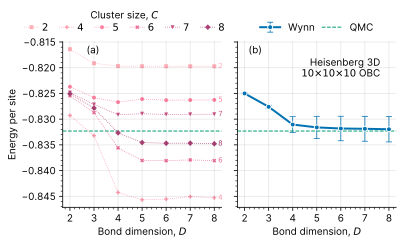

In [7]:
cm = xyz.cmoke(+0.0, reverse=True, hue_shift=+0.1)

max_sizes = [2, 4, 5, 6, 7, 8, 9, 10]
clust_colors = dict(zip(max_sizes, cm(np.linspace(0.0, 1.0, len(max_sizes)))))
# clust_markers = {C: f"${C}$" for C in [2, 4, 5, 6, 7, 8, 9, 10]}
clust_markers = {C: "." for C in clust_colors}

clust_markers = dict(
    zip(
        clust_colors,
        (
            "s",
            "P",
            "o",
            "X",
            "v",
            "D",
            "^",
            "h",
            "p",
            "*",
            "<",
            "d",
            "8",
            ">",
            "H",
        ),
    )
)

clust_linestyle = ":"
clust_linewidth = 0.75
clust_markersize = 4

fig, axs = plt.subplots(
    1, 2, figsize=(6, 3), sharey=True, gridspec_kw={"wspace": 0.1}
)

capsize = 3
elinewidth = 0.75
capthick = elinewidth
color_wynn = (
    get_color("bluedark")
    # "black"
)

wynn_style = dict(
    linewidth=2.0,
    color=color_wynn,
    marker="o",
    markeredgecolor="white",
    markersize=5,
    capsize=capsize,
    elinewidth=elinewidth,
    capthick=capthick,
)

model = "heis"
geom = "cubic_obc"
L = 10

ds = xyz.load_ds(f"../data/energy_gloop_expand_{model}_{geom}.h5").squeeze()
ref = simpclustlib.get_energy_reference(model, geom, L)
simpclustlib.estimate_gloop_stats_into_ds(
    ds, y=y, mode=mode, mode_err=mode_err
)

ds = ds.sel(D=slice(2, None))

datax = ds.sel(L=L)["D"].values
datay = ds.sel(L=L)[yest].values
dataye = ds.sel(L=L)[yerr].values
# dataye = None

ax = axs[1]
ax.text(0.07, 0.93, "(b)", transform=ax.transAxes)
ax.set(
    xlabel="Bond dimension, $D$",
    xticks=[2, 3, 4, 5, 6, 7, 8],
)

hand0 = ax.errorbar(
    datax,
    datay,
    dataye,
    **wynn_style,
    label="Wynn",
)
ax.text(
    0.9,
    0.9,
    "Heisenberg 3D\n$10{{\\times}}10{{\\times}}10$ OBC",
    transform=ax.transAxes,
    horizontalalignment="right",
    verticalalignment="top",
    # fontsize=10,
)
hand1 = ax.axhline(ref, color=get_color("green"), ls="--", lw=1, label="QMC")

ax.legend(
    handles=[hand0, hand1],
    loc="lower center",
    bbox_to_anchor=(0.5, 1.0),
    ncol=2,
    columnspacing=0.7,
)

ax = axs[0]
ax.set_ylabel("Energy per site")
ax.set(
    xlabel="Bond dimension, $D$",
    xticks=[2, 3, 4, 5, 6, 7, 8],
)

ax.axhline(ref, color=get_color("green"), ls="--", lw=1, zorder=-11)
label_offsets = {}

for max_size in ds["max_size"].values:
    datax = ds.sel(L=L)["D"].values
    datay = ds.sel(L=L, max_size=max_size)[y].values
    max_size = max(2, max_size)
    ax.plot(
        datax,
        datay,
        linewidth=clust_linewidth,
        markeredgewidth=0,
        zorder=-10,
        markersize=clust_markersize,
        linestyle=clust_linestyle,
        marker=clust_markers[max_size],
        color=clust_colors[max_size],
        label=f"${max_size}$",
    )
    ax.text(
        datax[-1],
        datay[-1] + label_offsets.get(max_size, 0),
        f"  ${max_size}$",
        ha="left",
        va="center",
        fontsize=7,
        color=clust_colors[max_size],
    )

ax.legend(
    ncol=9,
    bbox_to_anchor=(-0.3, 1.0),
    bbox_transform=ax.transAxes,
    loc="lower left",
    handlelength=1.5,
    labelspacing=0.3,
    handletextpad=0.3,
    columnspacing=1.1,
    title="Cluster size, $C$",
)
ax.text(0.15, 0.93, "(a)", transform=ax.transAxes)

plt.show()
plt.close()

In [8]:
fig.savefig(
    "fig-models-energy-vs-D-with-C-heis.png",
    dpi=300,
    bbox_inches="tight",
)

# fermi hubbard 2d

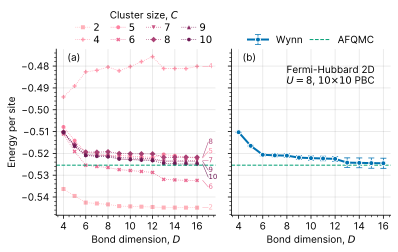

In [9]:
cm = xyz.cmoke(+0.0, reverse=True, hue_shift=+0.1)

max_sizes = [2, 4, 5, 6, 7, 8, 9, 10]
clust_colors = dict(zip(max_sizes, cm(np.linspace(0.0, 1.0, len(max_sizes)))))
# clust_markers = {C: f"${C}$" for C in [2, 4, 5, 6, 7, 8, 9, 10]}
clust_markers = {C: "." for C in clust_colors}

clust_markers = dict(
    zip(
        clust_colors,
        (
            "s",
            "P",
            "o",
            "X",
            "v",
            "D",
            "^",
            "h",
            "p",
            "*",
            "<",
            "d",
            "8",
            ">",
            "H",
        ),
    )
)

clust_linestyle = ":"
clust_linewidth = 0.75
clust_markersize = 4

fig, axs = plt.subplots(
    1, 2, figsize=(6, 3), sharey=True, gridspec_kw={"wspace": 0.1}
)

capsize = 3
elinewidth = 0.75
capthick = elinewidth
color_wynn = (
    get_color("bluedark")
    # "black"
)

wynn_style = dict(
    linewidth=2.0,
    color=color_wynn,
    marker="o",
    markeredgecolor="white",
    markersize=5,
    capsize=capsize,
    elinewidth=elinewidth,
    capthick=capthick,
)

model = "fermi_hubbard_U8"
geom = "square_pbc"
L = 10

ds = (
    xyz.load_ds(f"../data/energy_gloop_expand_{model}_{geom}.h5")
    .squeeze()
    .sel(L=L)
)
ref = simpclustlib.get_energy_reference(model, geom, L)
simpclustlib.estimate_gloop_stats_into_ds(
    ds, y=y, mode=mode, mode_err=mode_err
)

ds = ds.sel(D=slice(4, None))


#


ax = axs[1]
ax.text(0.07, 0.93, "(b)", transform=ax.transAxes)
ax.set(
    xlabel="Bond dimension, $D$",
    xticks=[4, 6, 8, 10, 12, 14, 16],
)

datax = ds["D"].values
datay = ds[yest].values
dataye = ds[yerr].values

hand0 = ax.errorbar(
    datax,
    datay,
    dataye,
    **wynn_style,
    label="Wynn",
)
hand1 = ax.axhline(ref, color=get_color("green"), ls="--", lw=1, label="AFQMC")

ax.text(
    0.9,
    0.9,
    "Fermi-Hubbard 2D\n$U=8$, $10{{\\times}}10$ PBC",
    transform=ax.transAxes,
    horizontalalignment="right",
    verticalalignment="top",
    # fontsize=10,
)

ax.legend(
    handles=[hand0, hand1],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.97),
    ncol=2,
    columnspacing=0.7,
)


#

ax = axs[0]
ax.set(
    xlabel="Bond dimension, $D$",
    xticks=[4, 6, 8, 10, 12, 14, 16],
)

ax.axhline(ref, color=get_color("green"), ls="--", lw=1)
label_offsets = {
    # 2: 0.001,
    # 4: 0.001,
    5: 0.003,
    6: -0.003,
    8: 0.007,
    9: -0.004,
    10: -0.006,
}
for max_size in ds["max_size"].values:
    datax = ds["D"].values
    datay = ds.sel(max_size=max_size)[y].values
    max_size = max(2, max_size)
    ax.plot(
        datax,
        datay,
        linewidth=clust_linewidth,
        markeredgewidth=0,
        zorder=-10,
        markersize=clust_markersize,
        linestyle=clust_linestyle,
        marker=clust_markers[max_size],
        color=clust_colors[max_size],
        label=f"${max_size}$",
    )
    ax.text(
        datax[-1] + 2 / 3,
        datay[-1] + label_offsets.get(max_size, 0),
        f"  ${max_size}$",
        ha="left",
        va="center",
        fontsize=7,
        color=clust_colors[max_size],
    )
    ax.plot(
        [datax[-1] + 0.5, datax[-1] + 1],
        [datay[-1], datay[-1] + label_offsets.get(max_size, 0)],
        color=clust_colors[max_size],
        linewidth=0.5,
    )
ax.set_ylabel("Energy per site")
ax.legend(
    ncol=4,
    bbox_to_anchor=(0.55, 0.97),
    bbox_transform=ax.transAxes,
    loc="lower center",
    handlelength=1.5,
    labelspacing=0.3,
    handletextpad=0.3,
    columnspacing=1.1,
    title="Cluster size, $C$",
)
ax.text(0.07, 0.93, "(a)", transform=ax.transAxes)

plt.show()
plt.close()

In [10]:
fig.savefig(
    "fig-models-energy-vs-D-with-C-fmhb2d.png",
    dpi=300,
    bbox_inches="tight",
)

# fermi hubbard 3d

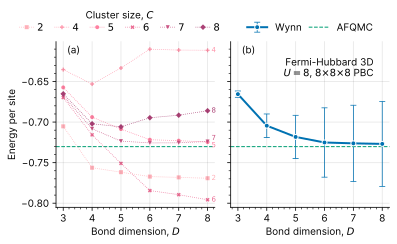

In [11]:
cm = xyz.cmoke(+0.0, reverse=True, hue_shift=+0.1)

max_sizes = [2, 4, 5, 6, 7, 8, 9, 10]
clust_colors = dict(zip(max_sizes, cm(np.linspace(0.0, 1.0, len(max_sizes)))))
# clust_markers = {C: f"${C}$" for C in [2, 4, 5, 6, 7, 8, 9, 10]}
clust_markers = {C: "." for C in clust_colors}

clust_markers = dict(
    zip(
        clust_colors,
        (
            "s",
            "P",
            "o",
            "X",
            "v",
            "D",
            "^",
            "h",
            "p",
            "*",
            "<",
            "d",
            "8",
            ">",
            "H",
        ),
    )
)

clust_linestyle = ":"
clust_linewidth = 0.75
clust_markersize = 4

fig, axs = plt.subplots(
    1, 2, figsize=(6, 3), sharey=True, gridspec_kw={"wspace": 0.1}
)

capsize = 3
elinewidth = 0.75
capthick = elinewidth
color_wynn = (
    get_color("bluedark")
    # "black"
)

wynn_style = dict(
    linewidth=2.0,
    color=color_wynn,
    marker="o",
    markeredgecolor="white",
    markersize=5,
    capsize=capsize,
    elinewidth=elinewidth,
    capthick=capthick,
)

model = "fermi_hubbard_U8"
geom = "cubic_pbc"
L = 8

ds = (
    xyz.load_ds(f"../data/energy_gloop_expand_{model}_{geom}.h5")
    .squeeze()
    .sel(L=L)
)
ref = simpclustlib.get_energy_reference(model, geom, L)
simpclustlib.estimate_gloop_stats_into_ds(
    ds, y=y, mode=mode, mode_err=mode_err
)

ds = ds.sel(D=slice(3, None))

ax = axs[1]
ax.text(0.07, 0.93, "(b)", transform=ax.transAxes)
ax.set(
    xlabel="Bond dimension, $D$",
    xticks=[3, 4, 5, 6, 7, 8],
)

datax = ds["D"].values
datay = ds[yest].values
dataye = ds[yerr].values

hand0 = ax.errorbar(
    datax,
    datay,
    dataye,
    **wynn_style,
    label="Wynn",
)
hand1 = ax.axhline(
    -0.73026, color=get_color("green"), ls="--", lw=1, label="AFQMC"
)
ax.text(
    0.9,
    0.9,
    "Fermi-Hubbard 3D\n$U=8$, $8{{\\times}}8{{\\times8}}$ PBC",
    transform=ax.transAxes,
    horizontalalignment="right",
    verticalalignment="top",
    # fontsize=10,
)

ax.legend(
    handles=[hand0, hand1],
    loc="lower center",
    bbox_to_anchor=(0.5, 1.0),
    ncol=2,
    columnspacing=0.7,
)


ax = axs[0]
ax.set(
    xlabel="Bond dimension, $D$",
    xticks=[3, 4, 5, 6, 7, 8],
)

ax.axhline(-0.73026, color=get_color("green"), ls="--", lw=1)
label_offsets = {
    7: +0.004,
    5: -0.004,
}
for max_size in ds["max_size"].values:
    datax = ds["D"].values
    datay = ds.sel(max_size=max_size)[y].values
    max_size = max(2, max_size)
    ax.plot(
        datax,
        datay,
        linewidth=clust_linewidth,
        markeredgewidth=0,
        zorder=-10,
        markersize=clust_markersize,
        linestyle=clust_linestyle,
        marker=clust_markers[max_size],
        color=clust_colors[max_size],
        label=f"${max_size}$",
    )
    ax.text(
        datax[-1],
        datay[-1] + label_offsets.get(max_size, 0),
        f"  ${max_size}$",
        ha="left",
        va="center",
        fontsize=7,
        color=clust_colors[max_size],
    )

ax.set_ylabel("Energy per site")
ax.legend(
    ncol=6,
    bbox_to_anchor=(0.4, 1.0),
    bbox_transform=ax.transAxes,
    loc="lower center",
    handlelength=1.5,
    labelspacing=0.3,
    handletextpad=0.3,
    columnspacing=1.1,
    title="Cluster size, $C$",
)
ax.text(0.07, 0.93, "(a)", transform=ax.transAxes)

plt.show()
plt.close()

In [12]:
fig.savefig(
    "fig-models-energy-vs-D-with-C-fmhb3d.png",
    dpi=300,
    bbox_inches="tight",
)